# Color-invariant saree design recognition

Match a saree by the motif on its surface, not by the palette it was dyed in. The model returns a 128-d embedding. Identification ranks a gallery by cosine similarity. Verification compares a pair with a threshold chosen on the validation split only.

## How to run on Kaggle

1. New Notebook, then File, Import Notebook, and select this file.
2. Add input: [Indian Saree Patterns](https://www.kaggle.com/datasets/div456/indian-saree-patterns).
3. Notebook options: GPU on, Internet on (needed once, to download ImageNet weights).
4. Run All. Metrics and plots are written to `/kaggle/working`.

The dataset path is discovered automatically. In a previous run of this input it was `/kaggle/input/datasets/div456/indian-saree-patterns`.

## Approach note (469 characters)

MobileNetV3-Small (ImageNet) maps a 224 crop to an L2 128-d embedding: small, fast, enough for repeating motifs. Preprocess: resize, center crop, ImageNet norm. Train adds flip, random crop, hue/saturation/brightness jitter, and grayscale, with two views per image. ArcFace separates design ids; NT-Xent matches the two views so color is not a cue. Post: cosine rank (identification) and a validation-only cosine threshold (verification). Official splits stay disjoint.

## What the labels actually are

`Banarasi`, `Bandhani`, `Ikat`, and `Pichwai` are weave families. They are not stock-keeping units, and this corpus has no photographed recolors of one design. Identity in the code is the folder name, so a finer corpus (one folder per design, several real colorways inside it) can replace this set without a code change.

Because those colorways are absent, color invariance is tested by recoloring held-out photos (hue, saturation, grayscale) and asking two questions:

- **Self-retrieval.** The gallery holds every test photo, including other photos of the same weave. The query is a recolored copy. Rank-1 means the nearest gallery photo is the source itself, so a weave-only shortcut is not enough.
- **Cross-image retrieval.** Gallery and query are disjoint photos. A hit is any gallery photo of the same identity. This is family-level identification.

Verification positives are a photo and its recoloring. Negatives are a different identity. A second pair type, two different photos of the same identity, is reported separately.


In [1]:
import math
import os
import random
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageEnhance
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42
IMG_SIZE = 224
EMBED_DIM = 128
EPOCHS = 10
ARCFACE_S = 30.0
ARCFACE_M = 0.30
ARCFACE_WEIGHT = 0.5
NTXENT_TEMPERATURE = 0.1
MAX_VAL_IMAGES = 256
NUM_WORKERS = 2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Set this only if automatic discovery picks the wrong folder.
DATASET_ROOT = None

APPROACH = (
    "MobileNetV3-Small (ImageNet) maps a 224 crop to an L2 128-d embedding: "
    "small, fast, enough for repeating motifs. Preprocess: resize, center crop, "
    "ImageNet norm. Train adds flip, random crop, hue/saturation/brightness jitter, "
    "and grayscale, with two views per image. ArcFace separates design ids; NT-Xent "
    "matches the two views so color is not a cue. Post: cosine rank (identification) "
    "and a validation-only cosine threshold (verification). Official splits stay disjoint."
)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"
if use_cuda:
    torch.backends.cudnn.benchmark = True

OUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch", torch.__version__)
print("Device", device)
if use_cuda:
    print("GPU", torch.cuda.get_device_name(0))
print("Approach characters", len(APPROACH))
print(APPROACH)


PyTorch 2.10.0+cu128
Device cuda
GPU Tesla T4
Approach characters 469
MobileNetV3-Small (ImageNet) maps a 224 crop to an L2 128-d embedding: small, fast, enough for repeating motifs. Preprocess: resize, center crop, ImageNet norm. Train adds flip, random crop, hue/saturation/brightness jitter, and grayscale, with two views per image. ArcFace separates design ids; NT-Xent matches the two views so color is not a cue. Post: cosine rank (identification) and a validation-only cosine threshold (verification). Official splits stay disjoint.


## Data

The loader looks under `/kaggle/input` for a directory that contains `train` and `valid` (or `val`). Images are read from the input mount. Nothing is copied into the working directory.


In [2]:
def find_dataset_root():
    if DATASET_ROOT is not None:
        root = Path(DATASET_ROOT)
        if not root.exists():
            raise FileNotFoundError(root)
        return root

    base = Path("/kaggle/input/datasets/div456/indian-saree-patterns")
    if not base.exists():
        raise FileNotFoundError(
            "No /kaggle/input. Attach div456/indian-saree-patterns and run this on Kaggle."
        )

    candidates = []
    for dirpath, dirnames, _ in os.walk(base):
        names = set(dirnames)
        if "train" in names and ("valid" in names or "val" in names):
            candidates.append(Path(dirpath))
    if not candidates:
        raise FileNotFoundError(
            "Attached inputs have no train/valid folders. Add indian-saree-patterns."
        )
    candidates.sort(key=lambda path: (len(path.parts), str(path)))
    return candidates[0]


def split_dir(root, split):
    if split == "valid" and not (root / "valid").exists() and (root / "val").exists():
        return root / "val"
    return root / split


def index_split(root, split):
    folder = split_dir(root, split)
    if not folder.exists():
        raise FileNotFoundError(folder)
    records = []
    skipped = 0
    for class_dir in sorted(path for path in folder.iterdir() if path.is_dir()):
        for image_path in class_dir.rglob("*"):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            try:
                with Image.open(image_path) as image:
                    image.convert("RGB").load()
            except Exception:
                skipped += 1
                continue
            records.append(
                {
                    "path": str(image_path),
                    "label": class_dir.name,
                    "split": split,
                }
            )
    print(f"{split}: {len(records)} images, skipped {skipped}")
    return records


dataset_root = find_dataset_root()
print("Dataset root:", dataset_root)

train_records = index_split(dataset_root, "train")
valid_records = index_split(dataset_root, "valid")
test_records = index_split(dataset_root, "test")

classes = sorted({record["label"] for record in train_records})
label_to_idx = {name: index for index, name in enumerate(classes)}
valid_records = [record for record in valid_records if record["label"] in label_to_idx]
test_records = [record for record in test_records if record["label"] in label_to_idx]

print("Identities:", classes)


def counts(records):
    tally = defaultdict(int)
    for record in records:
        tally[record["label"]] += 1
    return dict(tally)


count_table = pd.DataFrame(
    {
        "train": counts(train_records),
        "valid": counts(valid_records),
        "test": counts(test_records),
    }
).fillna(0).astype(int)
count_table


Dataset root: /kaggle/input/datasets/div456/indian-saree-patterns
train: 1293 images, skipped 0
valid: 115 images, skipped 0
test: 60 images, skipped 0
Identities: ['Banarasi', 'Bandhani', 'Ikat', 'Pichwai']


,train,valid,test
Banarasi,432,43,14
Bandhani,279,22,15
Ikat,303,26,13
Pichwai,279,24,18


## Preprocessing

Training draws two independent views of each photo. Hue is jittered across the whole circle, saturation and brightness move, and a quarter of views are grayscale. The only stable signal left between the two views is spatial structure.

Evaluation uses a deterministic resize and center crop. Recolors for the test protocol are applied in HSV before that crop, with the same functions for every split.


In [3]:
def build_train_transform():
    return transforms.Compose(
        [
            transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.8,
                hue=0.5,
            ),
            transforms.RandomGrayscale(p=0.25),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


def build_eval_transform():
    return transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


train_transform = build_train_transform()
eval_transform = build_eval_transform()


def hue_shift(image, degrees):
    hsv = np.array(image.convert("HSV"))
    shift = int(round((degrees / 360.0) * 255))
    hsv[:, :, 0] = (hsv[:, :, 0].astype(np.int16) + shift) % 256
    return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")


def saturation_shift(image, factor):
    return ImageEnhance.Color(image).enhance(factor)


def grayscale(image):
    return image.convert("L").convert("RGB")


COLOR_VARIANTS = {
    "original": lambda image: image,
    "hue_plus_90": lambda image: hue_shift(image, 90),
    "hue_minus_90": lambda image: hue_shift(image, -90),
    "hue_180": lambda image: hue_shift(image, 180),
    "saturation_low": lambda image: saturation_shift(image, 0.25),
    "grayscale": grayscale,
}


class TwoViewDataset(Dataset):
    """Two color-jittered views and the identity index."""

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        for offset in range(8):
            record = self.records[(index + offset) % len(self.records)]
            try:
                with Image.open(record["path"]) as image:
                    image = image.convert("RGB")
                view_a = train_transform(image.copy())
                view_b = train_transform(image.copy())
                return view_a, view_b, label_to_idx[record["label"]]
            except Exception:
                continue
        raise RuntimeError("Could not read a training image")


def choose_batch_size(num_images, target=64):
    if num_images < 2:
        raise RuntimeError("Need at least 2 training images")
    return min(target, num_images)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BATCH_SIZE = choose_batch_size(len(train_records))
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    TwoViewDataset(train_records),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=len(train_records) > BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=use_cuda,
    worker_init_fn=seed_worker,
    generator=generator,
)
print("Batch size", BATCH_SIZE, "steps", len(train_loader))


Batch size 64 steps 20


## Model and loss

MobileNetV3-Small keeps the convolutional stack and replaces the classifier with global average pooling, a bias-free linear map, and batch-norm. The vector is L2-normalized so cosine similarity is a dot product.

ArcFace (`s=30`, `m=0.30`) is applied to the weave or design id. Its weight is `0.5` on this corpus because a four-way family label would otherwise pull unrelated motifs of the same weave into one point, which hurts exact-photo retrieval. Raise `ARCFACE_WEIGHT` when each folder is one design.

NT-Xent is computed on the 2N views in the batch. The partner of each view is its other recoloring. That term is what forces palette invariance.


In [4]:
class Embedder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        try:
            weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
            backbone = models.mobilenet_v3_small(weights=weights)
        except Exception as error:
            raise RuntimeError(
                "ImageNet weights did not download. In notebook settings, turn Internet on."
            ) from error
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        with torch.no_grad():
            channels = self.features(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)).shape[1]
        self.fc = nn.Linear(channels, embed_dim, bias=False)
        self.bn = nn.BatchNorm1d(embed_dim)
        nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, images):
        features = self.pool(self.features(images))
        embedding = self.bn(self.fc(features.flatten(1)))
        return F.normalize(embedding, dim=1)


class ArcFace(nn.Module):
    def __init__(self, embed_dim, num_classes, scale, margin):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_margin = math.cos(margin)
        self.sin_margin = math.sin(margin)
        self.threshold = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - cosine.square()).clamp(min=0.0, max=1.0))
        phi = cosine * self.cos_margin - sine * self.sin_margin
        phi = torch.where(cosine > self.threshold, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        return logits * self.scale


def nt_xent(view_a, view_b, temperature):
    batch = view_a.shape[0]
    z = torch.cat([view_a, view_b], dim=0)
    similarity = z @ z.T / temperature
    diagonal = torch.eye(similarity.shape[0], device=similarity.device, dtype=torch.bool)
    similarity = similarity.masked_fill(diagonal, -1e4)
    targets = torch.cat(
        [
            torch.arange(batch, 2 * batch, device=z.device),
            torch.arange(0, batch, device=z.device),
        ]
    )
    return F.cross_entropy(similarity, targets)


model = Embedder(EMBED_DIM).to(device)
arcface = ArcFace(EMBED_DIM, len(classes), ARCFACE_S, ARCFACE_M).to(device)

optimizer = torch.optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(), "lr": 1e-3},
        {"params": model.bn.parameters(), "lr": 1e-3},
        {"params": arcface.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_cuda)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)

print("Inference parameters", sum(p.numel() for p in model.parameters()))


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 233MB/s]


Inference parameters 1000992


## Training

Each step encodes both views, applies ArcFace to each, and adds NT-Xent between them. The checkpoint kept for test is the one with the best validation invariance score, not the last epoch.


In [5]:
@torch.no_grad()
def embed_paths(color_fn, records, batch_size=64):
    model.eval()
    chunks = []
    paths = [record["path"] for record in records]
    for start in range(0, len(paths), batch_size):
        tensors = []
        for path in paths[start : start + batch_size]:
            with Image.open(path) as image:
                image = color_fn(image.convert("RGB"))
            tensors.append(eval_transform(image))
        batch = torch.stack(tensors).to(device, non_blocking=use_cuda)
        with torch.amp.autocast("cuda", enabled=use_cuda):
            chunks.append(model(batch).float().cpu())
    return torch.cat(chunks, dim=0)


@torch.no_grad()
def invariance_score(records):
    pool = records.copy()
    random.Random(SEED).shuffle(pool)
    subset = pool[:MAX_VAL_IMAGES]
    if len(subset) < 2:
        return 0.0, 0.0, 0.0
    clean = embed_paths(COLOR_VARIANTS["original"], subset)
    shifted = embed_paths(COLOR_VARIANTS["hue_plus_90"], subset)
    self_cosine = (clean * shifted).sum(dim=1).mean().item()
    labels = np.array([record["label"] for record in subset])
    similarity = clean @ clean.T
    different = labels[:, None] != labels[None, :]
    inter = float(similarity.numpy()[different].mean()) if different.any() else 0.0
    return self_cosine - inter, self_cosine, inter


def run_epoch(epoch):
    model.train()
    arcface.train()
    totals = defaultdict(float)
    steps = 0
    for view_a, view_b, labels in train_loader:
        view_a = view_a.to(device, non_blocking=use_cuda)
        view_b = view_b.to(device, non_blocking=use_cuda)
        labels = labels.to(device, non_blocking=use_cuda)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=use_cuda):
            embed_a = model(view_a)
            embed_b = model(view_b)
        embed_a = embed_a.float()
        embed_b = embed_b.float()
        loss_id = 0.5 * (
            F.cross_entropy(arcface(embed_a, labels), labels)
            + F.cross_entropy(arcface(embed_b, labels), labels)
        )
        loss_color = nt_xent(embed_a, embed_b, NTXENT_TEMPERATURE)
        loss = ARCFACE_WEIGHT * loss_id + loss_color
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(arcface.parameters()),
            1.0,
        )
        scaler.step(optimizer)
        scaler.update()
        totals["loss"] += float(loss.detach())
        totals["id"] += float(loss_id.detach())
        totals["color"] += float(loss_color.detach())
        steps += 1
    scheduler.step()
    return {key: value / max(steps, 1) for key, value in totals.items()}


best_score = -1e9
best_epoch = 0
best_val = 0.0
best_path = OUT_DIR / "best_embedder.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(epoch)
    score, self_cosine, inter_cosine = invariance_score(valid_records)
    history.append(
        {
            "epoch": epoch,
            **train_loss,
            "val_score": score,
            "val_self_cosine": self_cosine,
            "val_inter_cosine": inter_cosine,
        }
    )
    print(
        f"epoch {epoch:02d}  loss {train_loss['loss']:.3f}  "
        f"id {train_loss['id']:.3f}  color {train_loss['color']:.3f}  "
        f"val self {self_cosine:.3f}  inter {inter_cosine:.3f}  score {score:.3f}"
    )
    if score > best_score:
        best_score = score
        best_epoch = epoch
        best_val = score
        torch.save(model.state_dict(), best_path)

model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
model.eval()
print("Best epoch", best_epoch, "val score", round(best_val, 4))
pd.DataFrame(history)


/tmp/ipykernel_58/1677154832.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")


epoch 01  loss 4.552  id 6.946  color 1.079  val self 0.844  inter 0.117  score 0.727
epoch 02  loss 2.400  id 3.278  color 0.761  val self 0.864  inter 0.021  score 0.843
epoch 03  loss 1.640  id 2.028  color 0.626  val self 0.873  inter -0.010  score 0.882
epoch 04  loss 1.346  id 1.482  color 0.605  val self 0.869  inter -0.045  score 0.914
epoch 05  loss 1.080  id 1.055  color 0.552  val self 0.869  inter -0.051  score 0.920
epoch 06  loss 0.853  id 0.699  color 0.503  val self 0.867  inter -0.065  score 0.932
epoch 07  loss 0.818  id 0.672  color 0.482  val self 0.868  inter -0.063  score 0.931
epoch 08  loss 0.736  id 0.517  color 0.477  val self 0.866  inter -0.065  score 0.931
epoch 09  loss 0.736  id 0.549  color 0.462  val self 0.864  inter -0.069  score 0.933
epoch 10  loss 0.711  id 0.448  color 0.487  val self 0.863  inter -0.069  score 0.933
Best epoch 10 val score 0.9326


,epoch,loss,id,color,val_score,val_self_cosine,val_inter_cosine
0,1,4.552290,6.945950,1.079315,0.727392,0.843910,0.116518
1,2,2.399677,3.278123,0.760615,0.842805,0.864147,0.021342
2,3,1.639537,2.028046,0.625515,0.882381,0.872718,-0.009664
3,4,1.345852,1.482253,0.604726,0.913836,0.869043,-0.044794
4,5,1.079978,1.055094,0.552431,0.919956,0.868751,-0.051204
5,6,0.852790,0.698746,0.503417,0.931801,0.867091,-0.064711
6,7,0.818343,0.671962,0.482363,0.931004,0.868184,-0.062820
7,8,0.735704,0.516890,0.477259,0.930769,0.865577,-0.065192
8,9,0.736344,0.549495,0.461597,0.932610,0.863841,-0.068769
9,10,0.711341,0.448157,0.487262,0.932641,0.863231,-0.069410


## Evaluation protocol

- **Train** learns the embedding. **Valid** picks the checkpoint and the verification threshold. **Test** is scored once.
- No file is in more than one split. The published `train` / `valid` / `test` folders are used as-is.
- Cross-image gallery and query are a seeded 50/50 split inside the test folder, stratified by identity. Paths do not overlap.
- Similarity is cosine similarity of L2-normalized embeddings.
- Identification reports Rank-1, Rank-5, and mean average precision.
- The same-palette control recolors the gallery with the same function as the query, so a leftover dye color cannot explain a hit.
- The verification threshold is the equal-error threshold on validation. Test receives that frozen threshold, plus ROC-AUC, equal-error rate, and true accept rate at 1% false accept rate.
- Checkpoint selection uses validation images only: mean cosine between a photo and its hue-shifted copy, minus mean cosine to other identities.


In [6]:
def average_precision(ranked_labels, query_label):
    hits = (ranked_labels == query_label).astype(np.float64)
    if hits.sum() == 0:
        return 0.0
    precision = np.cumsum(hits) / (np.arange(len(hits)) + 1.0)
    return float((precision * hits).sum() / hits.sum())


def retrieval_metrics(similarity, query_labels, gallery_labels):
    order = np.argsort(-similarity, axis=1)
    gallery_labels = np.asarray(gallery_labels)
    query_labels = np.asarray(query_labels)
    rank1 = 0
    rank5 = 0
    aps = []
    for row, query_label in enumerate(query_labels):
        ranked = gallery_labels[order[row]]
        matches = np.flatnonzero(ranked == query_label)
        if len(matches) == 0:
            aps.append(0.0)
            continue
        rank = int(matches[0]) + 1
        rank1 += int(rank <= 1)
        rank5 += int(rank <= 5)
        aps.append(average_precision(ranked, query_label))
    count = len(query_labels)
    return {
        "n": count,
        "rank1": rank1 / count,
        "rank5": rank5 / count,
        "mAP": float(np.mean(aps)),
    }


def self_retrieval(similarity):
    predicted = similarity.argmax(axis=1)
    target = np.arange(similarity.shape[0])
    return float((predicted == target).mean())


def stratified_split(records, seed):
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for record in records:
        grouped[record["label"]].append(record)
    gallery, query = [], []
    for items in grouped.values():
        items = items.copy()
        rng.shuffle(items)
        if len(items) < 2:
            continue
        cut = max(1, len(items) // 2)
        if cut == len(items):
            cut = len(items) - 1
        gallery.extend(items[:cut])
        query.extend(items[cut:])
    return gallery, query


def pairwise_similarity(left, right):
    return (left * right).sum(dim=1).numpy()


gallery_records, query_records = stratified_split(test_records, SEED)
print("Cross-image gallery", len(gallery_records), "query", len(query_records))
if len(gallery_records) == 0 or len(query_records) == 0:
    raise RuntimeError("Each identity needs at least two test images for cross-image retrieval.")

identification_rows = []
gallery_clean = embed_paths(COLOR_VARIANTS["original"], gallery_records)
gallery_labels = [record["label"] for record in gallery_records]

for name, color_fn in COLOR_VARIANTS.items():
    query_embed = embed_paths(color_fn, query_records)
    similarity = (query_embed @ gallery_clean.T).numpy()
    metrics = retrieval_metrics(
        similarity,
        [record["label"] for record in query_records],
        gallery_labels,
    )
    metrics["variant"] = name
    metrics["gallery"] = "original"
    identification_rows.append(metrics)
    if name == "original":
        continue

    # Same transform on the gallery: shared palette is no longer evidence.
    gallery_shifted = embed_paths(color_fn, gallery_records)
    shifted_similarity = (query_embed @ gallery_shifted.T).numpy()
    shifted_metrics = retrieval_metrics(
        shifted_similarity,
        [record["label"] for record in query_records],
        gallery_labels,
    )
    shifted_metrics["variant"] = name
    shifted_metrics["gallery"] = "same_transform"
    identification_rows.append(shifted_metrics)

cross_image = pd.DataFrame(identification_rows)
print("\nCross-image identification")
print(cross_image.round(4).to_string(index=False))

self_rows = []
test_clean = embed_paths(COLOR_VARIANTS["original"], test_records)
for name, color_fn in COLOR_VARIANTS.items():
    query_embed = embed_paths(color_fn, test_records)
    similarity = (query_embed @ test_clean.T).numpy()
    self_rows.append(
        {
            "variant": name,
            "self_rank1": self_retrieval(similarity),
            "mean_cosine_to_source": float(np.diag(similarity).mean()),
            "n": len(test_records),
        }
    )

self_retrieval_table = pd.DataFrame(self_rows)
print("\nSelf-retrieval under recolor (exact photo must be rank 1)")
print(self_retrieval_table.round(4).to_string(index=False))


Cross-image gallery 29 query 31


/tmp/ipykernel_58/1677154832.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")



Cross-image identification
 n  rank1  rank5    mAP        variant        gallery
31 0.8065 0.9032 0.7682       original       original
31 0.7742 0.9032 0.7500    hue_plus_90       original
31 0.8387 0.9032 0.7570    hue_plus_90 same_transform
31 0.7419 0.9355 0.7739   hue_minus_90       original
31 0.7742 0.9032 0.7820   hue_minus_90 same_transform
31 0.8065 0.9677 0.7938        hue_180       original
31 0.8387 0.9032 0.7998        hue_180 same_transform
31 0.8065 0.9355 0.7760 saturation_low       original
31 0.8065 0.9032 0.7741 saturation_low same_transform
31 0.7419 0.9355 0.7661      grayscale       original
31 0.8065 0.9355 0.7648      grayscale same_transform


/tmp/ipykernel_58/1677154832.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")



Self-retrieval under recolor (exact photo must be rank 1)
       variant  self_rank1  mean_cosine_to_source  n
      original      1.0000                 1.0000 60
   hue_plus_90      0.9667                 0.8710 60
  hue_minus_90      0.9333                 0.8913 60
       hue_180      0.9667                 0.8634 60
saturation_low      1.0000                 0.9559 60
     grayscale      0.9833                 0.9034 60


## Verification

The primary pairs test the brief directly: a photo and a recolored copy are the same design, and a photo from another identity is not. Negatives include both a clean distractor and a distractor recolored by the same hue shift, so matching a palette is not enough.

The threshold is the validation equal-error threshold. It is not refit on test.


In [7]:
def cosine_matrix(left, right):
    return (left @ right.T).numpy()


def sample_pair_scores(clean, labels, shifted, n_pairs, seed, same_label):
    rng = random.Random(seed)
    labels = np.asarray(labels)
    grouped = defaultdict(list)
    for index, label in enumerate(labels):
        grouped[label].append(index)
    identities = [label for label, indexes in grouped.items() if len(indexes) >= 1]
    scores = []
    attempts = 0
    while len(scores) < n_pairs and attempts < n_pairs * 30:
        attempts += 1
        if same_label:
            candidates = [label for label in identities if len(grouped[label]) >= 2]
            if not candidates:
                break
            label = rng.choice(candidates)
            left, right = rng.sample(grouped[label], 2)
        else:
            if len(identities) < 2:
                break
            left_label, right_label = rng.sample(identities, 2)
            left = rng.choice(grouped[left_label])
            right = rng.choice(grouped[right_label])
        scores.append(float((clean[left] * shifted[right]).sum()))
    return np.asarray(scores, dtype=np.float64)


def pack_verification(clean, hue, labels, n_pairs, seed):
    labels = np.asarray(labels)
    color_positive = pairwise_similarity(clean, hue)
    n_pos = min(n_pairs, len(color_positive))
    if n_pos < len(color_positive):
        pick = np.random.default_rng(seed).choice(len(color_positive), n_pos, replace=False)
        color_positive = color_positive[pick]
    half = max(1, n_pos // 2)
    cross_positive = sample_pair_scores(clean, labels, clean, n_pos, seed, True)
    negative_for_cross = sample_pair_scores(clean, labels, clean, n_pos, seed + 3, False)
    negative_clean = sample_pair_scores(clean, labels, clean, half, seed + 1, False)
    negative_recolored = sample_pair_scores(clean, labels, hue, n_pos - half, seed + 2, False)
    primary_scores = np.concatenate([color_positive, negative_clean, negative_recolored])
    primary_labels = np.concatenate(
        [
            np.ones(len(color_positive)),
            np.zeros(len(negative_clean) + len(negative_recolored)),
        ]
    )
    secondary_scores = np.concatenate([cross_positive, negative_for_cross])
    secondary_labels = np.concatenate(
        [np.ones(len(cross_positive)), np.zeros(len(negative_for_cross))]
    )
    for pair_scores, pair_labels in (
        (primary_scores, primary_labels),
        (secondary_scores, secondary_labels),
    ):
        if len(pair_scores) < 2 or len(np.unique(pair_labels)) < 2:
            raise RuntimeError("Not enough positive and negative pairs to score verification.")
    return {
        "recolor_vs_other": (primary_scores, primary_labels),
        "cross_photo_vs_other": (secondary_scores, secondary_labels),
    }


def equal_error_threshold(scores, labels):
    false_accept, true_accept, thresholds = roc_curve(labels, scores)
    false_reject = 1.0 - true_accept
    index = int(np.nanargmin(np.abs(false_accept - false_reject)))
    threshold = float(thresholds[index]) if index < len(thresholds) else 0.0
    eer = float((false_accept[index] + false_reject[index]) / 2.0)
    return threshold, eer, false_accept, true_accept


def tar_at_far(false_accept, true_accept, far=0.01):
    allowed = np.flatnonzero(false_accept <= far)
    if len(allowed) == 0:
        return 0.0
    return float(true_accept[allowed[-1]])


def evaluate_verification(scores, labels, threshold):
    auc = float(roc_auc_score(labels, scores))
    _, eer, false_accept, true_accept = equal_error_threshold(scores, labels)
    decisions = (scores >= threshold).astype(np.int64)
    accuracy = float((decisions == labels.astype(np.int64)).mean())
    return {
        "auc": auc,
        "eer": eer,
        "tar_at_far_1pct": tar_at_far(false_accept, true_accept),
        "accuracy_at_valid_threshold": accuracy,
        "threshold": threshold,
        "n": int(len(labels)),
        "n_positive": int(labels.sum()),
    }


N_PAIRS = 2000
valid_clean = embed_paths(COLOR_VARIANTS["original"], valid_records)
valid_hue = embed_paths(COLOR_VARIANTS["hue_plus_90"], valid_records)
test_hue = embed_paths(COLOR_VARIANTS["hue_plus_90"], test_records)
valid_labels = [record["label"] for record in valid_records]
test_labels = [record["label"] for record in test_records]

valid_pairs = pack_verification(valid_clean, valid_hue, valid_labels, N_PAIRS, SEED)
test_pairs = pack_verification(test_clean, test_hue, test_labels, N_PAIRS, SEED + 7)

verification_rows = []
for pair_name in valid_pairs:
    valid_scores, valid_y = valid_pairs[pair_name]
    test_scores, test_y = test_pairs[pair_name]
    threshold, valid_eer, _, _ = equal_error_threshold(valid_scores, valid_y)
    metrics = evaluate_verification(test_scores, test_y, threshold)
    metrics["pair_type"] = pair_name
    metrics["valid_eer"] = valid_eer
    verification_rows.append(metrics)

verification = pd.DataFrame(verification_rows)
print(verification.round(4).to_string(index=False))


/tmp/ipykernel_58/1677154832.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")


   auc    eer  tar_at_far_1pct  accuracy_at_valid_threshold  threshold   n  n_positive            pair_type  valid_eer
0.9994 0.0250           0.9833                       0.9833     0.3356 120          60     recolor_vs_other     0.0000
0.8758 0.1833           0.0667                       0.8167     0.0649 120          60 cross_photo_vs_other     0.1913


## Efficiency

Inference uses the embedding network only. The ArcFace layer is a training head and is not counted in the inference parameter total. Latency is a single 224 input on the active device, after warmup. FLOPs come from PyTorch's flop counter when that API is available.


                        item     value
        inference_parameters   1000992
parameters_with_arcface_head   1001504
               embedding_dim       128
                       input       224
           latency_ms_batch1     4.884
          latency_ms_batch32     7.333
latency_ms_per_image_batch32     0.229
             flops_one_image 109940608
                  best_epoch        10
                      device      cuda


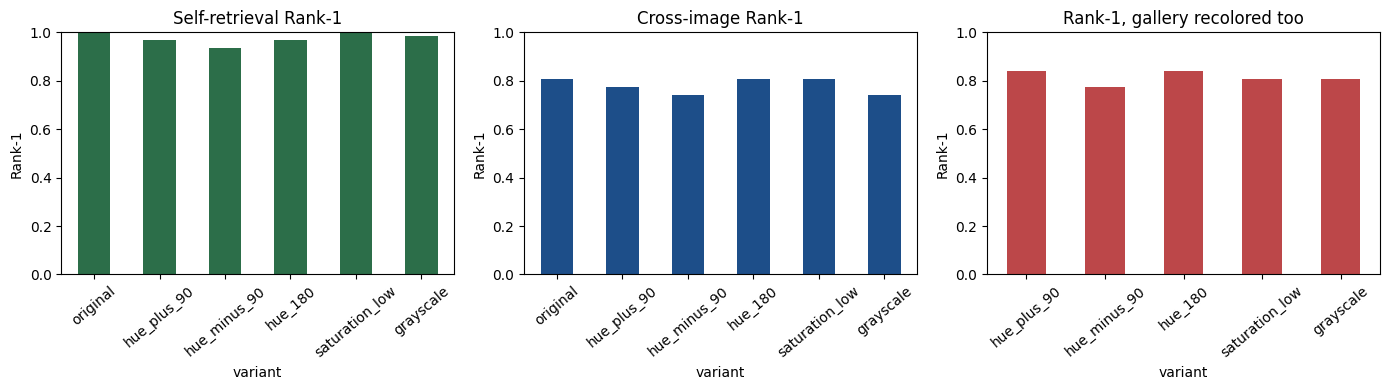

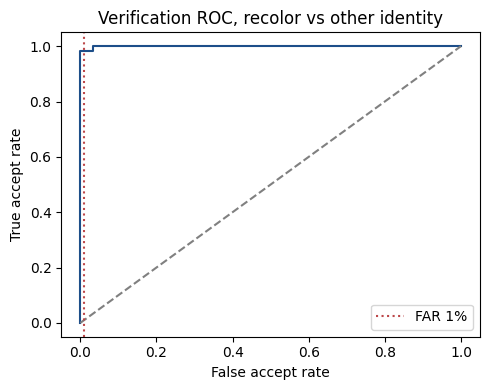

/tmp/ipykernel_58/1677154832.py:38: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(hsv.astype(np.uint8), mode="HSV").convert("RGB")


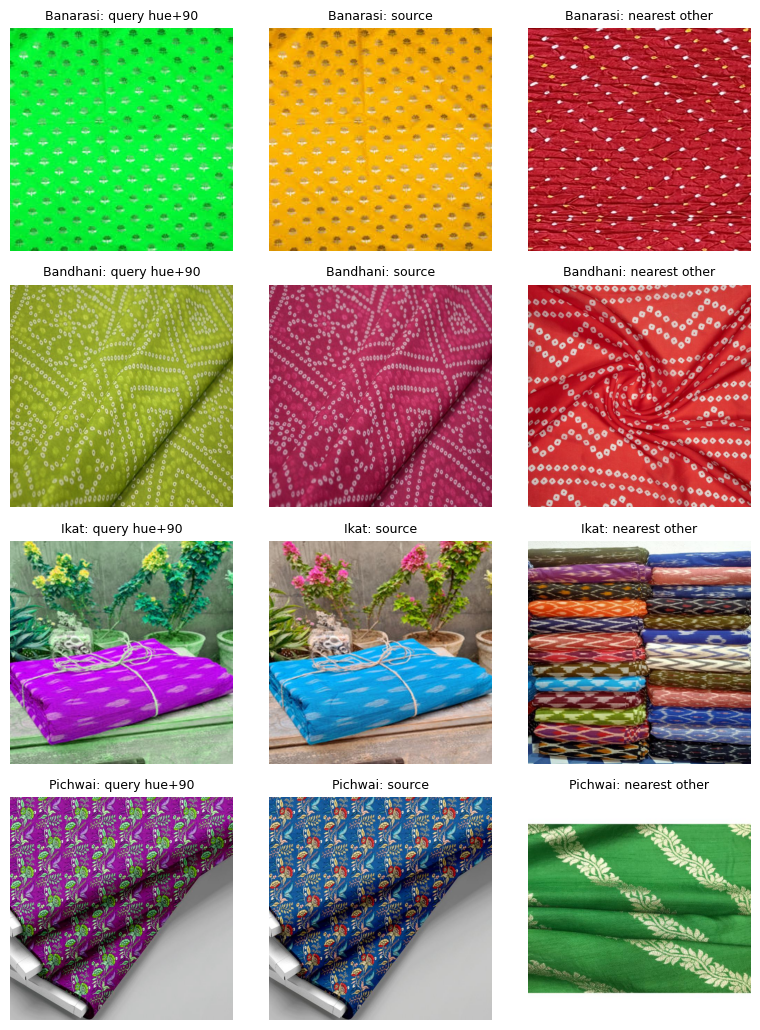


Headline results
Self Rank-1, hue+90: 0.967. Grayscale: 0.983. Original sanity check: 1.000.
Cross-image Rank-1, original queries: 0.806. Hue+90 queries: 0.774. mAP original: 0.768.
Verification AUC 0.999, EER 0.025, TAR@1%FAR 0.983, threshold 0.336.
Saved under /kaggle/working


In [8]:
def inference_latency_ms(batch_size, repeats=50):
    dummy = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=device)
    model.eval()
    with torch.no_grad():
        for _ in range(10):
            model(dummy)
        if use_cuda:
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(repeats):
            model(dummy)
        if use_cuda:
            torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return elapsed / repeats * 1000.0


def count_flops():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    try:
        from torch.utils.flop_counter import FlopCounterMode

        with torch.no_grad(), FlopCounterMode(display=False) as counter:
            model(dummy)
        if hasattr(counter, "get_total_flops"):
            return int(counter.get_total_flops())
        return int(sum(counter.flop_counts["Global"].values()))
    except Exception as error:
        print("FLOP counter unavailable:", error)
        return None


latency_1 = inference_latency_ms(1)
latency_32 = inference_latency_ms(32)
flops = count_flops()
inference_params = sum(p.numel() for p in model.parameters())
trainable_params = inference_params + sum(p.numel() for p in arcface.parameters())

efficiency = pd.DataFrame(
    [
        {"item": "inference_parameters", "value": inference_params},
        {"item": "parameters_with_arcface_head", "value": trainable_params},
        {"item": "embedding_dim", "value": EMBED_DIM},
        {"item": "input", "value": IMG_SIZE},
        {"item": "latency_ms_batch1", "value": round(latency_1, 3)},
        {"item": "latency_ms_batch32", "value": round(latency_32, 3)},
        {"item": "latency_ms_per_image_batch32", "value": round(latency_32 / 32.0, 3)},
        {"item": "flops_one_image", "value": flops if flops is not None else "unavailable"},
        {"item": "best_epoch", "value": int(best_epoch)},
        {"item": "device", "value": str(device)},
    ]
)
print(efficiency.to_string(index=False))

original = cross_image[
    (cross_image["gallery"] == "original")
].set_index("variant")[["rank1", "rank5", "mAP"]]
same_palette = cross_image[
    (cross_image["gallery"] == "same_transform")
].set_index("variant")["rank1"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
self_retrieval_table.set_index("variant")["self_rank1"].plot(
    kind="bar", ax=axes[0], color="#2c6e49", rot=40
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Self-retrieval Rank-1")
axes[0].set_ylabel("Rank-1")

original["rank1"].plot(kind="bar", ax=axes[1], color="#1d4e89", rot=40)
axes[1].set_ylim(0, 1)
axes[1].set_title("Cross-image Rank-1")
axes[1].set_ylabel("Rank-1")

same_palette.plot(kind="bar", ax=axes[2], color="#bc4749", rot=40)
axes[2].set_ylim(0, 1)
axes[2].set_title("Rank-1, gallery recolored too")
axes[2].set_ylabel("Rank-1")
fig.tight_layout()
fig.savefig(OUT_DIR / "identification.png", dpi=140)
plt.show()

valid_scores, valid_y = valid_pairs["recolor_vs_other"]
test_scores, test_y = test_pairs["recolor_vs_other"]
threshold, _, _, _ = equal_error_threshold(valid_scores, valid_y)
false_accept, true_accept, _ = roc_curve(test_y, test_scores)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(false_accept, true_accept, color="#1d4e89")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False accept rate")
ax.set_ylabel("True accept rate")
ax.set_title("Verification ROC, recolor vs other identity")
ax.axvline(0.01, color="#bc4749", linestyle=":", label="FAR 1%")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "verification_roc.png", dpi=140)
plt.show()

# One qualitative row per identity: recolored query, source, nearest other photo.
preview = []
shown = set()
for record in test_records:
    if record["label"] in shown:
        continue
    shown.add(record["label"])
    preview.append(record)
    if len(preview) == len(classes):
        break

preview_clean = embed_paths(COLOR_VARIANTS["original"], preview)
preview_hue = embed_paths(COLOR_VARIANTS["hue_plus_90"], preview)
catalog = test_clean
catalog_paths = [record["path"] for record in test_records]
fig, axes = plt.subplots(len(preview), 3, figsize=(8, 2.6 * len(preview)))
if len(preview) == 1:
    axes = np.array([axes])
for row, record in enumerate(preview):
    similarity = (preview_hue[row : row + 1] @ catalog.T).numpy().ravel()
    source_index = catalog_paths.index(record["path"])
    masked = similarity.copy()
    masked[source_index] = -1.0
    neighbor = int(masked.argmax())
    panels = [
        (COLOR_VARIANTS["hue_plus_90"], record["path"], "query hue+90"),
        (COLOR_VARIANTS["original"], record["path"], "source"),
        (COLOR_VARIANTS["original"], catalog_paths[neighbor], "nearest other"),
    ]
    for column, (color_fn, path, title) in enumerate(panels):
        with Image.open(path) as image:
            image = color_fn(image.convert("RGB"))
        axes[row, column].imshow(image)
        axes[row, column].set_title(f"{record['label']}: {title}", fontsize=9)
        axes[row, column].axis("off")
fig.tight_layout()
fig.savefig(OUT_DIR / "retrieval_examples.png", dpi=140)
plt.show()

cross_image.to_csv(OUT_DIR / "identification.csv", index=False)
self_retrieval_table.to_csv(OUT_DIR / "self_retrieval.csv", index=False)
verification.to_csv(OUT_DIR / "verification.csv", index=False)
efficiency.to_csv(OUT_DIR / "efficiency.csv", index=False)
pd.DataFrame(history).to_csv(OUT_DIR / "training_history.csv", index=False)

headline_self = self_retrieval_table.set_index("variant")
headline_cross = original
recolor_verification = verification.set_index("pair_type").loc["recolor_vs_other"]
print("\nHeadline results")
print(
    f"Self Rank-1, hue+90: {headline_self.loc['hue_plus_90', 'self_rank1']:.3f}. "
    f"Grayscale: {headline_self.loc['grayscale', 'self_rank1']:.3f}. "
    f"Original sanity check: {headline_self.loc['original', 'self_rank1']:.3f}."
)
print(
    f"Cross-image Rank-1, original queries: {headline_cross.loc['original', 'rank1']:.3f}. "
    f"Hue+90 queries: {headline_cross.loc['hue_plus_90', 'rank1']:.3f}. "
    f"mAP original: {headline_cross.loc['original', 'mAP']:.3f}."
)
print(
    f"Verification AUC {recolor_verification['auc']:.3f}, "
    f"EER {recolor_verification['eer']:.3f}, "
    f"TAR@1%FAR {recolor_verification['tar_at_far_1pct']:.3f}, "
    f"threshold {recolor_verification['threshold']:.3f}."
)
print("Saved under", OUT_DIR)
